## Fig 1 genes analysis 

Restricting the censat regions to count genes in to just the regions used in CHM13

In [1]:
import os
import glob
import pandas as pd

In [ ]:
### visualizing CHM13 arrays and the gene content. 

In [2]:
def map_to_sat_category(raw):
    if raw is None: return "other"
    if   re.match(r'active_hor', raw, re.I): return "active_hor"
    elif re.match(r'dhor',       raw, re.I): return "dhor"
    elif re.match(r'hor',        raw, re.I): return "hor"
    elif re.match(r'mixedalpha', raw, re.I): return "mixedAlpha"
    elif re.match(r'mon',        raw, re.I): return "mon"
    elif re.search(r'hsat1',     raw, re.I): return "HSAT1"
    elif re.search(r'hsat2',     raw, re.I): return "HSAT2"
    elif re.search(r'hsat3',     raw, re.I): return "HSAT3"
    elif re.search(r'hsat4',     raw, re.I): return "HSAT4"
    elif re.search(r'hsat5',     raw, re.I): return "HSAT5"
    elif re.match(r'bsat',       raw, re.I): return "bSat"
    elif re.match(r'gsat',       raw, re.I): return "gSat"
    elif re.match(r'ct',         raw, re.I): return "CT"
    elif re.search(r'satr',      raw, re.I): return "SATR"
    elif re.search(r'sst1',      raw, re.I): return "SST1"
    elif re.search(r'cer',       raw, re.I): return "CER"
    elif re.search(r'rdna|5srna',raw, re.I): return "rDNA"
    elif re.search(r'acro',      raw, re.I): return "acrocentric"
    else:                                     return "other"


In [16]:
import pandas as pd
import re

# ── censat BED ────────────────────────────────────────────────────────────────
censat_bed = pd.read_csv(
    '/private/groups/migalab/juklucas/censat_regions/censat_beds/chm13v2.0_censat_v2.1.bed',
    sep='\t', header=None,
    names=['chrom','start','end','name','score','strand','thick_start','thick_end','rgb']
)
censat_bed['color'] = censat_bed['rgb'].apply(
    lambda x: tuple(int(v)/255 for v in x.split(','))
)
censat_bed['sat_cat'] = censat_bed['name'].apply(map_to_sat_category)

# ── genes TSV ─────────────────────────────────────────────────────────────────
genes_df = pd.read_csv(
    '/private/groups/patenlab/mira/databaseS08_GeneExpression.tsv',
    sep='\t', comment='#',
    names=['chrom','start','end','name','ensID','CATv4','gene_biotype',
           'novel','salmon','iso','rna_k21','pro_k21','between_satellites_nonacro']
)
genes_df['start'] = genes_df['start'].astype(int)
genes_df['end']   = genes_df['end'].astype(int)

print(f"censat rows: {len(censat_bed)}")
print(f"gene rows:   {len(genes_df)}")
print(f"gene biotypes: {genes_df['gene_biotype'].value_counts().head(6).to_dict()}")


censat rows: 2523
gene rows:   61497
gene biotypes: {'protein_coding': 19869, 'lncRNA': 17383, 'processed_pseudogene': 10523, 'unprocessed_pseudogene': 2573, 'misc_RNA': 2158, 'miRNA': 1897}


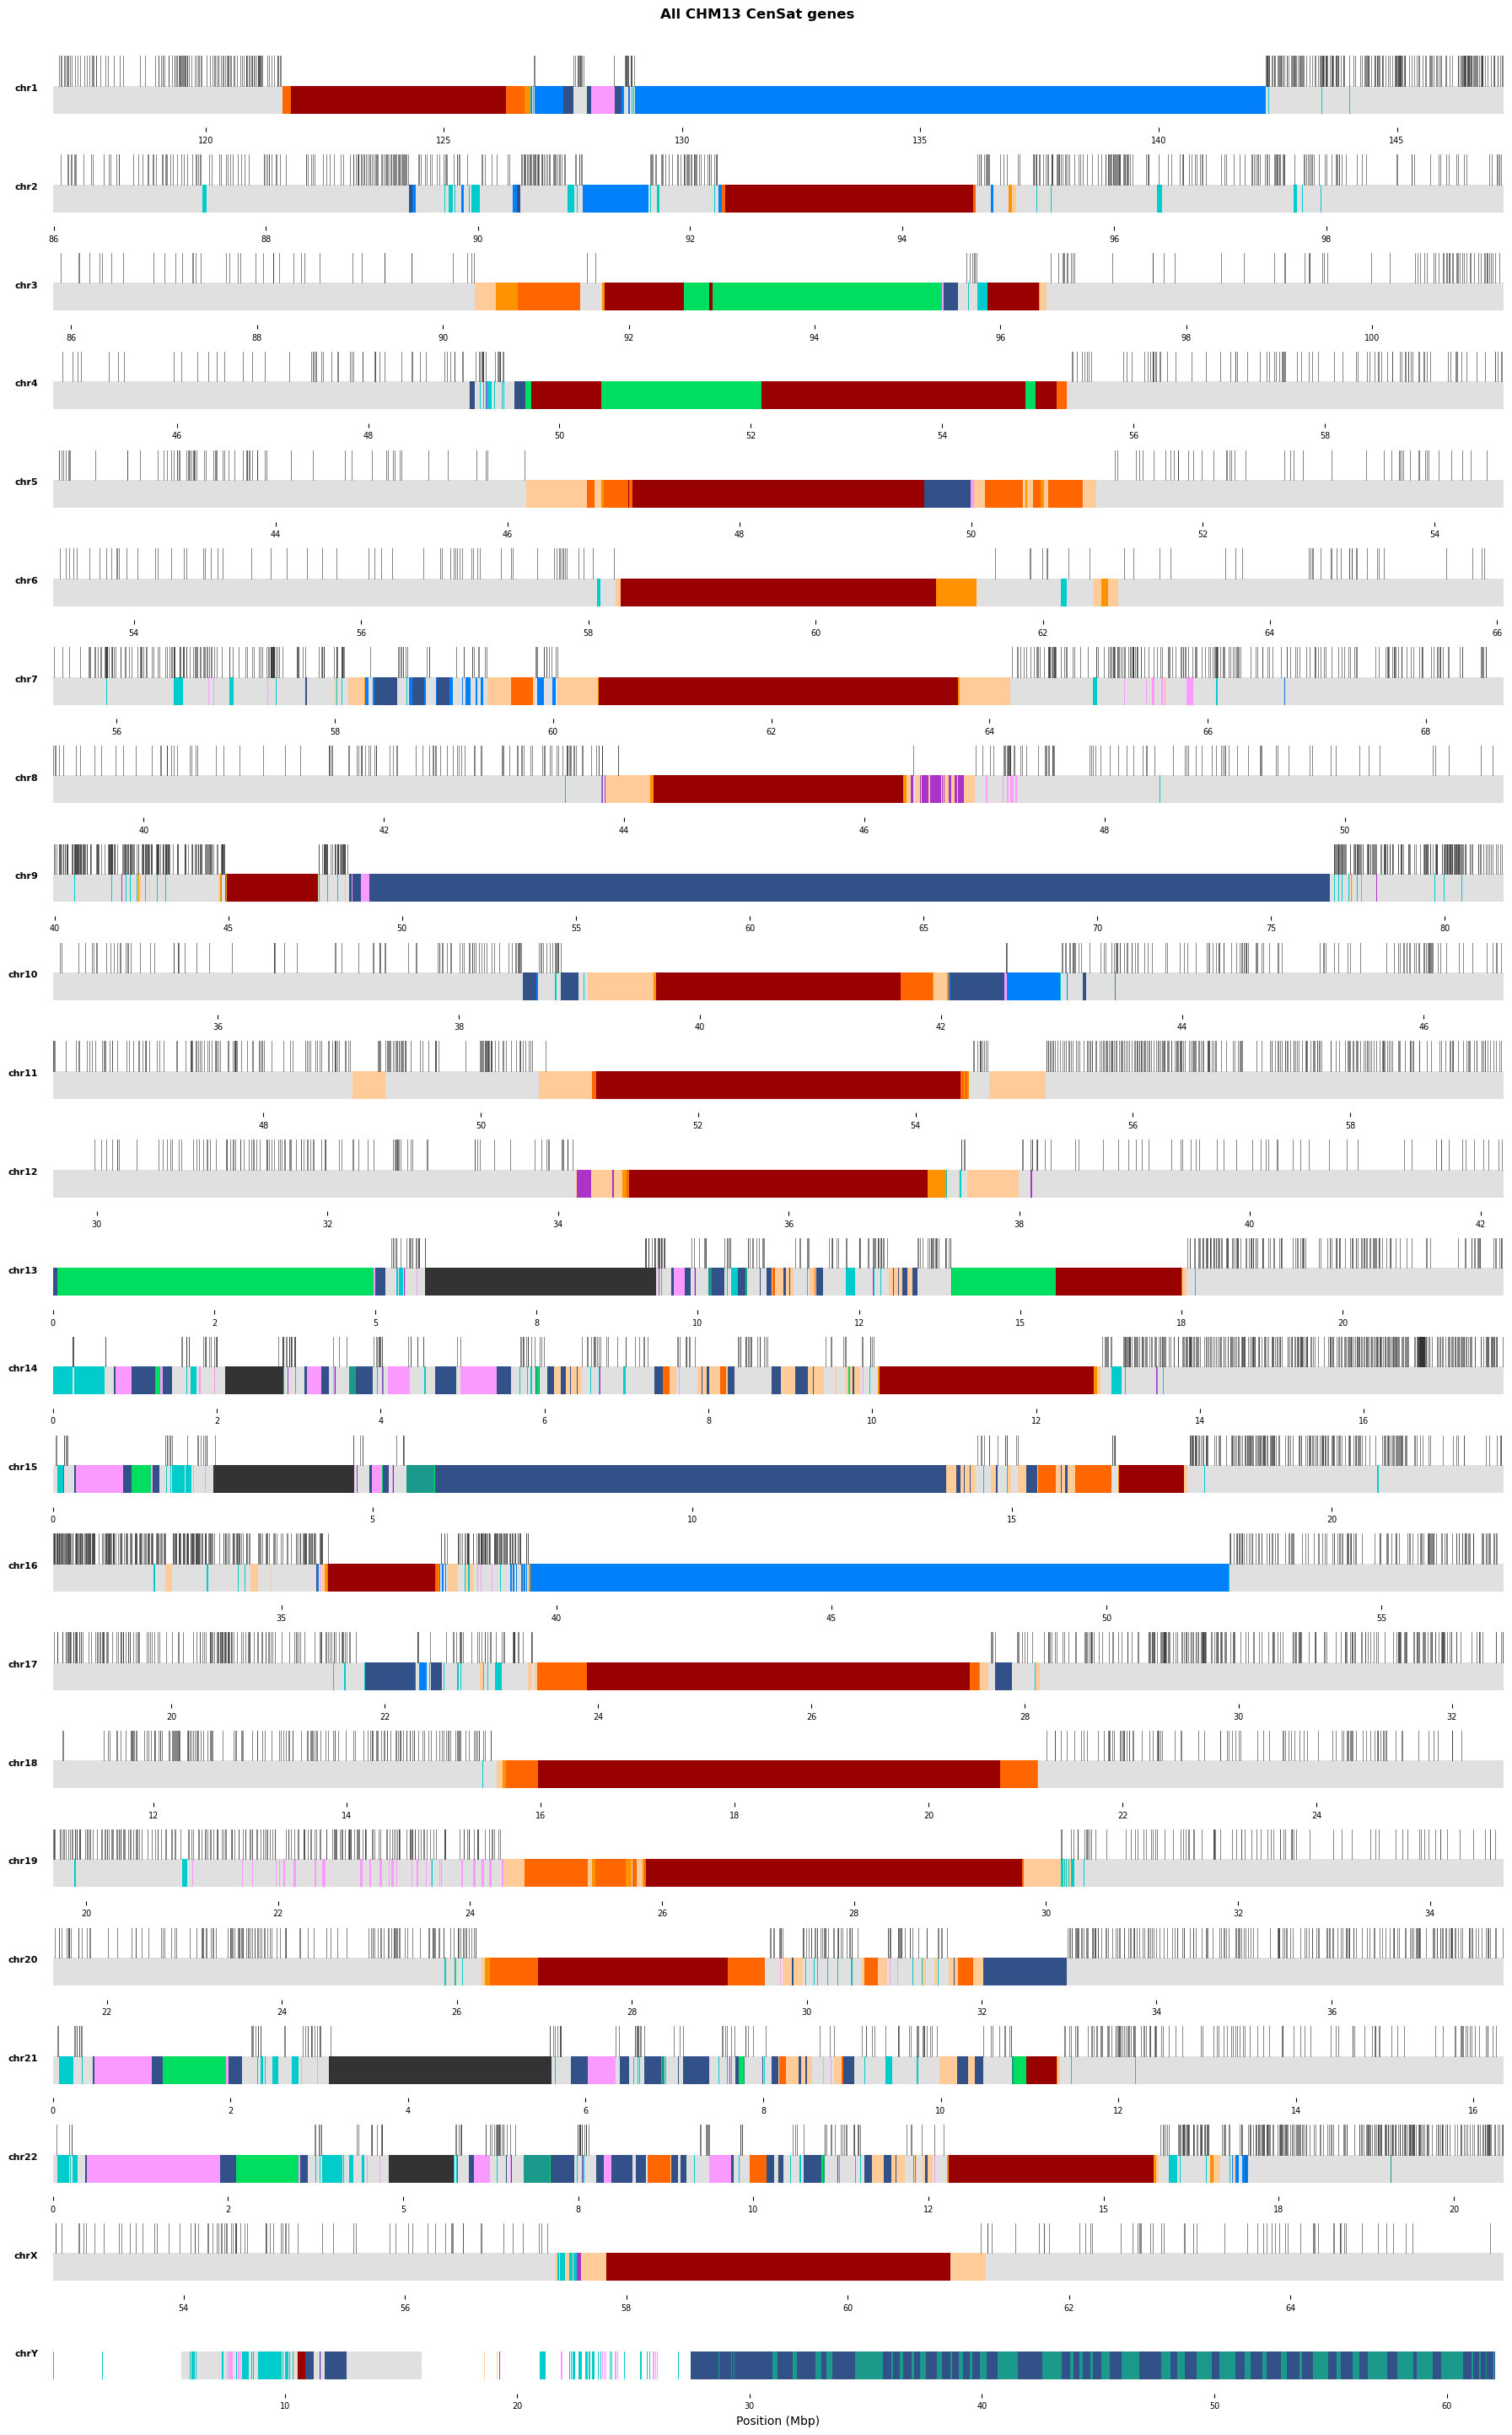

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

genes_filt = genes_df.copy()

ARRAY_H  = 0.35   # height of censat bar
GENE_Y   = 0.55   # y offset above array center for gene ticks
ROW_H    = 1.2    # total row height per chrom

fig, axes = plt.subplots(len(CHROM_ORDER), 1,
                         figsize=(18, len(CHROM_ORDER) * ROW_H),
                         squeeze=False)

for row_i, chrom in enumerate(CHROM_ORDER):
    ax = axes[row_i, 0]

    cbed = censat_bed[censat_bed['chrom'] == chrom]
    cgenes = genes_filt[genes_filt['chrom'] == chrom]

    if len(cbed) == 0:
        ax.set_visible(False)
        continue

    x_min, x_max = cbed['start'].min(), cbed['end'].max()

    # ── censat array bars ─────────────────────────────────────────────────────
    for _, seg in cbed.iterrows():
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], -ARRAY_H/2), seg['end'] - seg['start'], ARRAY_H,
            color=seg['color'], linewidth=0
        ))

    # ── gene tick marks ───────────────────────────────────────────────────────
    for _, g in cgenes.iterrows():
        mid = (g['start'] + g['end']) / 2
        ax.plot([mid, mid], [ARRAY_H/2, GENE_Y],
                color='#333333', lw=0.6, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-ARRAY_H, GENE_Y + 0.1)
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))

    # chrom label on left
    ax.text(-0.01, 0.5, chrom, transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='center', ha='right')

axes[-1, 0].set_xlabel('Position (Mbp)', fontsize=10)
fig.suptitle('All CHM13 CenSat genes',
             fontsize=12, fontweight='bold', y=1.001)

plt.tight_layout(h_pad=0.2)

plt.show()


In [7]:
print(genes_df['between_satellites_nonacro'].value_counts())


between_satellites_nonacro
False    60821
True       676
Name: count, dtype: int64


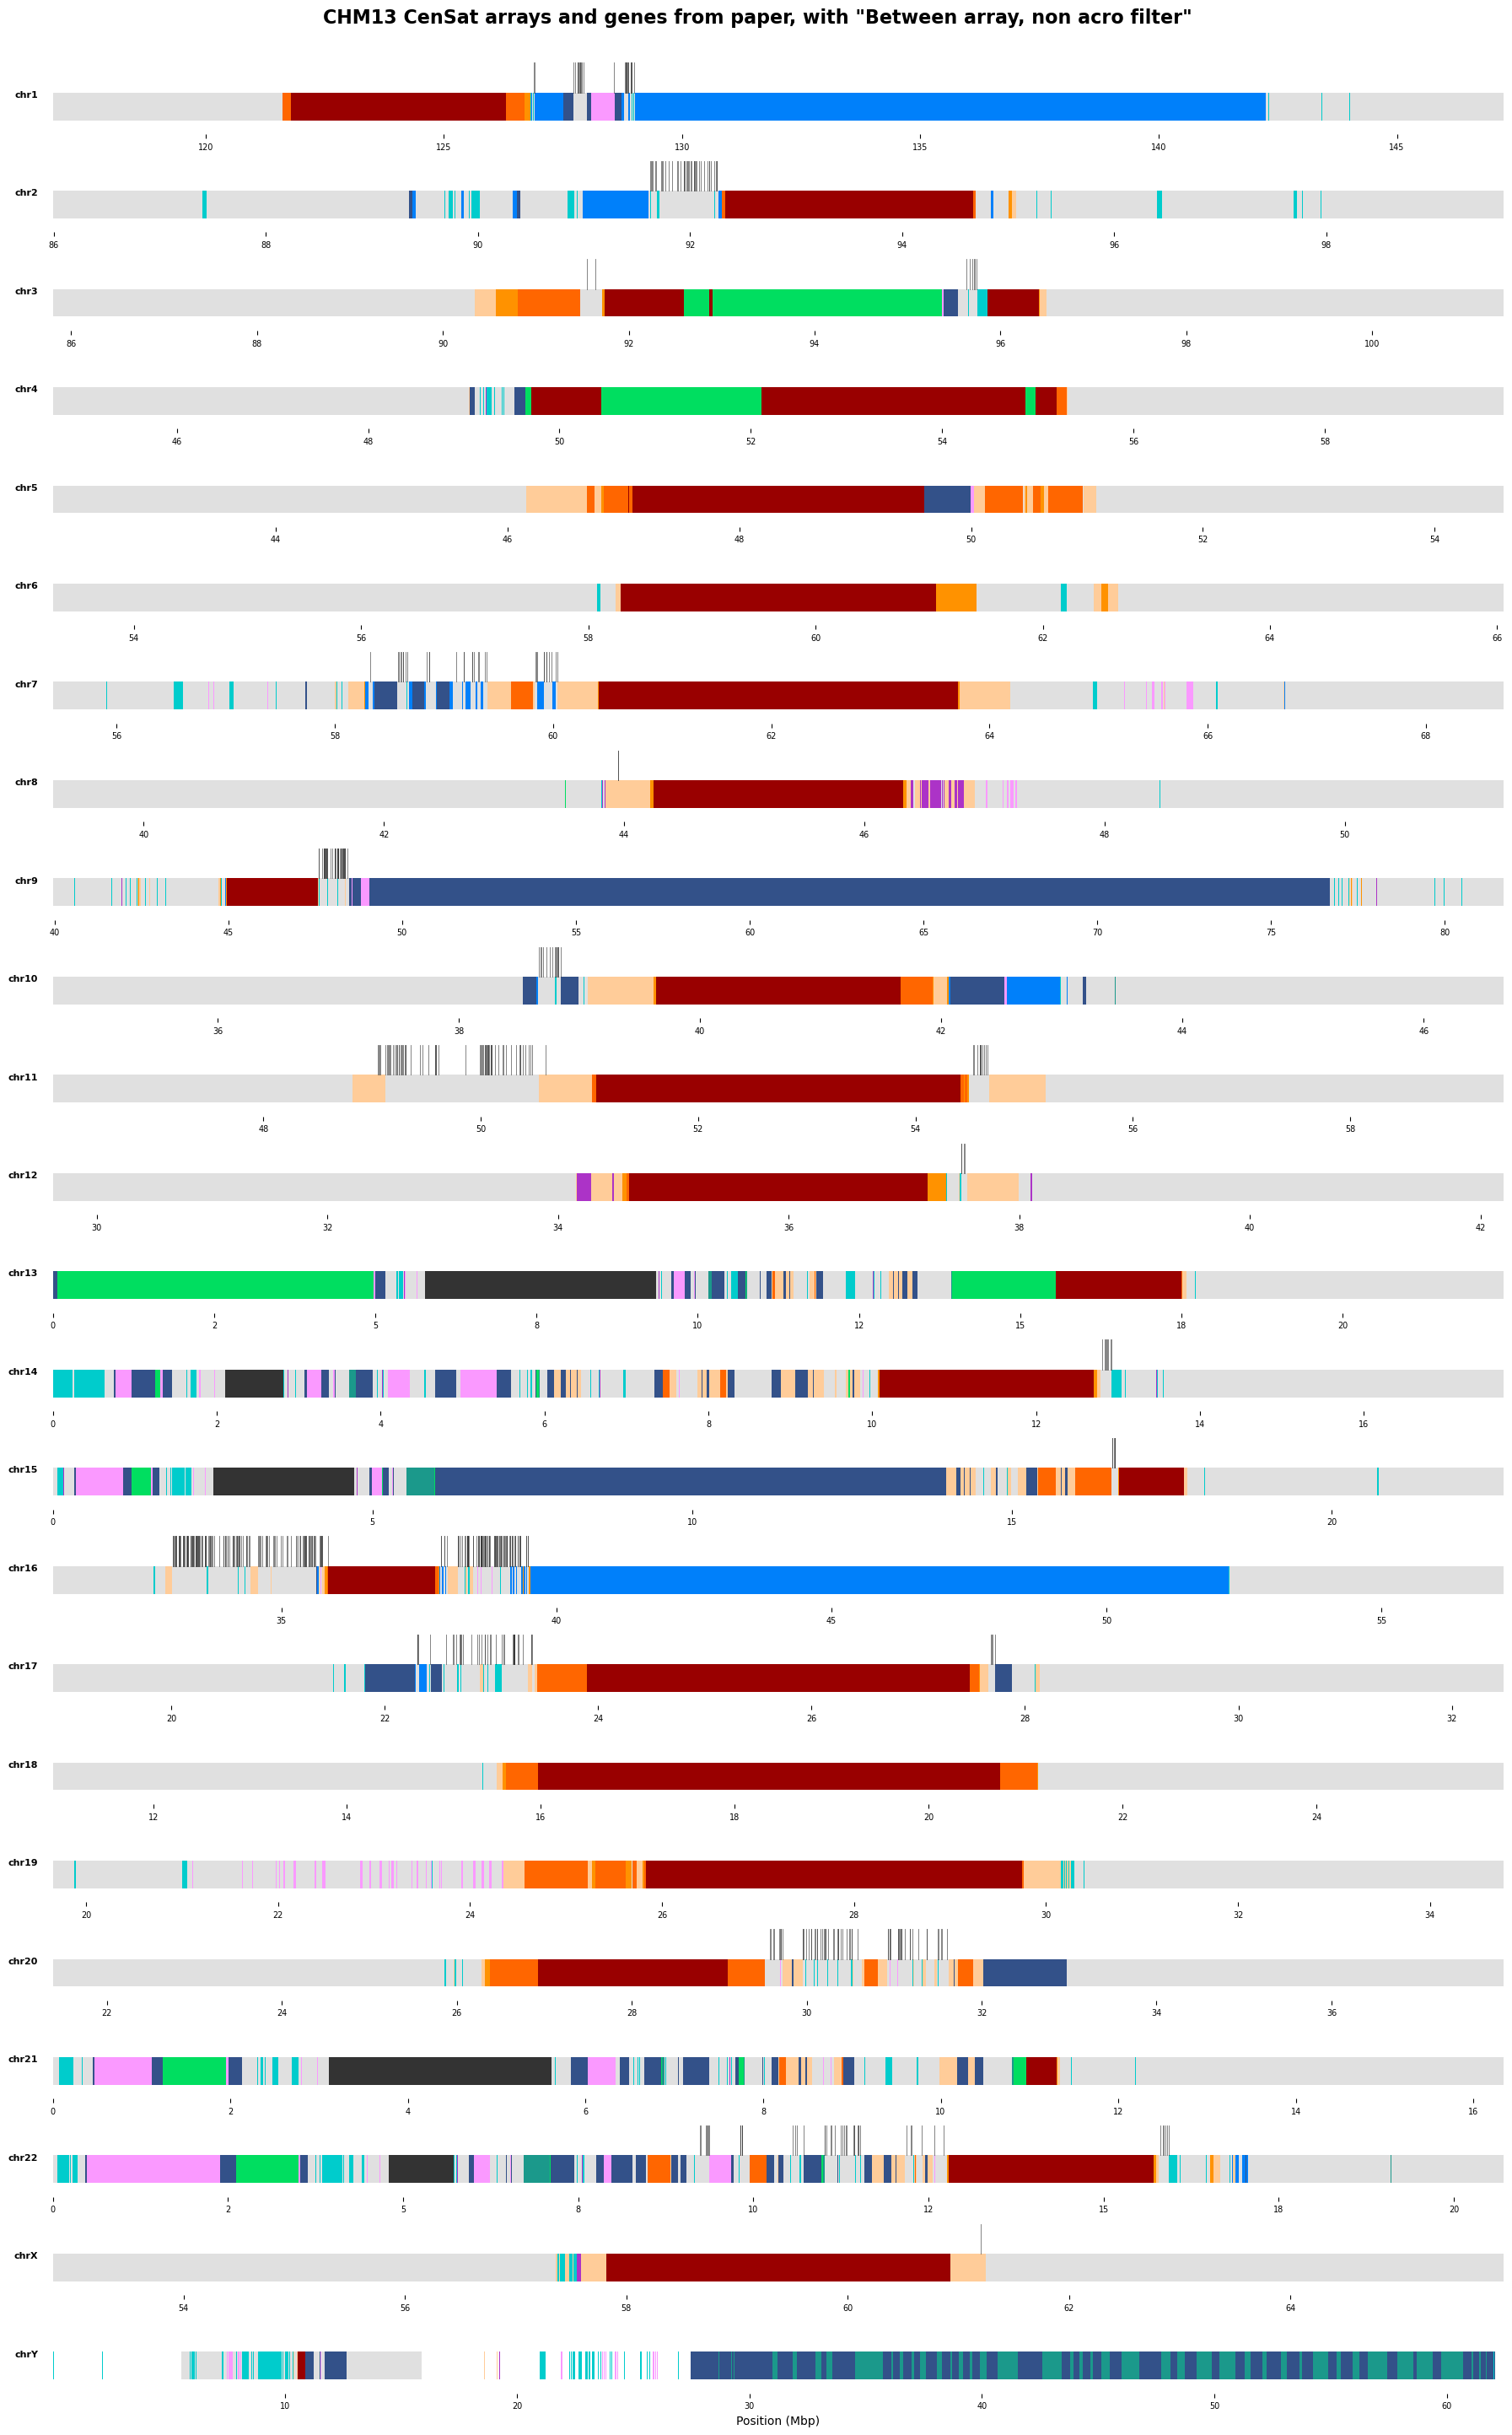

In [ ]:
### CHM13 genes reported in paper (between satellites and non acro filter)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

genes_filt = genes_df[genes_df['between_satellites_nonacro'] == True].copy()

ARRAY_H  = 0.35   # height of censat bar
GENE_Y   = 0.55   # y offset above array center for gene ticks
ROW_H    = 1.2    # total row height per chrom

fig, axes = plt.subplots(len(CHROM_ORDER), 1,
                         figsize=(18, len(CHROM_ORDER) * ROW_H),
                         squeeze=False)

for row_i, chrom in enumerate(CHROM_ORDER):
    ax = axes[row_i, 0]

    cbed = censat_bed[censat_bed['chrom'] == chrom]
    cgenes = genes_filt[genes_filt['chrom'] == chrom]

    if len(cbed) == 0:
        ax.set_visible(False)
        continue

    x_min, x_max = cbed['start'].min(), cbed['end'].max()

    # ── censat array bars ─────────────────────────────────────────────────────
    for _, seg in cbed.iterrows():
        ax.add_patch(mpatches.Rectangle(
            (seg['start'], -ARRAY_H/2), seg['end'] - seg['start'], ARRAY_H,
            color=seg['color'], linewidth=0
        ))

    # ── gene tick marks ───────────────────────────────────────────────────────
    for _, g in cgenes.iterrows():
        mid = (g['start'] + g['end']) / 2
        ax.plot([mid, mid], [ARRAY_H/2, GENE_Y],
                color='#333333', lw=0.6, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-ARRAY_H, GENE_Y + 0.1)
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))

    # chrom label on left
    ax.text(-0.01, 0.5, chrom, transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='center', ha='right')

axes[-1, 0].set_xlabel('Position (Mbp)', fontsize=10)
fig.suptitle('CHM13 CenSat genes, with "Between array, non acro filter"',
             fontsize=16, fontweight='bold', y=1.001)

plt.tight_layout(h_pad=0.2)

plt.show()


## Filtering HPRC data set by CHM13 rules

CHM13 paper reported: All gene annotations occurring between any peri/centromeric satellite annotations larger than 100 kb, excluding acrocentric short arms

In [ ]:
# CENSAT bed files
CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
# Censat regions definitions and arrays passing QC
CENSAT_TSV_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

In [5]:
# load array boundaries
all_tsvs = glob.glob(f'{CENSAT_TSV_DIR}/censat_regions_pass_qc_chr*.tsv')
regions_df = pd.concat([pd.read_csv(f, sep='\t') for f in all_tsvs], ignore_index=True)
regions_df = regions_df[regions_df['pass_qc'] == True][
    ['sample_id', 'haplotype', 'chrom_assignment', 'sequence_id', 'region_start', 'region_end', 'pass_qc']
].rename(columns={'chrom_assignment': 'chrom'})
regions_df['haplotype'] = regions_df['haplotype'].astype(str)

In [ ]:
## Read in HPRC censat genes annotated by whether they have > 100 kb satellites on both sides
import glob, re, os
import pandas as pd

ANNOT_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/satellite_neighbors'

def parse_attr(attr_str, key):
    m = re.search(rf'{key}=([^;]+)', attr_str)
    return m.group(1) if m else None

records = []
for path in glob.glob(f'{ANNOT_DIR}/*_sat_neighbors.tsv'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_(chr\w+)_sat_neighbors\.tsv', fname)
    if not m: continue
    sample_id = m.group(1)
    hap_raw   = m.group(2)
    chrom     = m.group(3)
    haplotype = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')

    df = pd.read_csv(path, sep='\t', header=0, low_memory=False)  # header=0: use first row
    df = df[df['feature'] == 'gene'].copy()

    df['sample_id']    = sample_id
    df['haplotype']    = haplotype
    df['chrom']        = chrom
    df['gene_name']    = df['attributes'].apply(lambda x: parse_attr(x, 'gene_name'))
    df['gene_biotype'] = df['attributes'].apply(lambda x: parse_attr(x, 'gene_biotype'))

    records.append(df[['sample_id', 'haplotype', 'chrom', 'contig',
                        'start', 'end', 'strand', 'gene_name', 'gene_biotype',
                        'between_satellites_100kb', 'on_acrocentric_short_arm']])

annot_df = pd.concat(records, ignore_index=True)
annot_df['start'] = annot_df['start'].astype(int)
annot_df['end']   = annot_df['end'].astype(int)

print(annot_df.shape)
display(annot_df.head())

(170894, 11)


,sample_id,haplotype,chrom,contig,start,end,strand,gene_name,gene_biotype,between_satellites_100kb,on_acrocentric_short_arm
0,NA19036,2,chr10,CM089743.1,38713766,38717957,+,ABCD1P2,unprocessed_pseudogene,True,False
1,NA19036,2,chr10,CM089743.1,38749985,38752159,+,PABPC1P12,processed_pseudogene,True,False
2,NA19036,2,chr10,CM089743.1,38755057,38803140,-,SLC9B1P3,transcribed_unprocessed_pseudogene,True,False
3,NA19036,2,chr10,CM089743.1,38810469,38811947,+,ACTR3BP5,processed_pseudogene,True,False
4,NA19036,2,chr10,CM089743.1,38827203,38833237,+,CHEK2P5,unprocessed_pseudogene,True,False


In [ ]:
## Ensure we're only keeping samples that pass QC
import os, glob, re

REGIONS_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

# Build set of (sample_id, normalized_hap, chrom) that pass QC
# normalized_hap: '1' or '2'
pass_qc = set()
for path in glob.glob(f'{REGIONS_DIR}/censat_regions_pass_qc_chr*.tsv'):
    m = re.match(r'.*censat_regions_pass_qc_(chr\w+)\.tsv', path)
    if not m: continue
    chrom = m.group(1)
    df_r = pd.read_csv(path, sep='\t', usecols=['sample_id', 'haplotype'])
    for _, row in df_r.iterrows():
        pass_qc.add((str(row['sample_id']), str(int(row['haplotype'])), chrom))

# Normalize haplotype in annot_df to '1'/'2' for matching
hap_norm = {'hap1': '1', 'hap2': '2', 'pat': '1', 'mat': '2',
            '1': '1', '2': '2'}

before = len(annot_df)
annot_df = annot_df[
    annot_df.apply(
        lambda r: (str(r['sample_id']),
                   hap_norm.get(str(r['haplotype']), str(r['haplotype'])),
                   r['chrom']) in pass_qc,
        axis=1)
].copy()
print(f"Rows before: {before:,}  →  after: {len(annot_df):,}")


Rows before: 170,894  →  after: 170,894


In [ ]:
## Visualize all the arrays and their genes (no filters)
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_all_genes.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55
GENE_TICK_H    = 0.30
GENE_GAP       = 0.05

# ── pre-index genes for fast per-haplotype lookup ─────────────────────────────
gene_lookup = {key: grp for key, grp in
               annot_df.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── build bed_map ─────────────────────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path

print(f"bed_map entries: {len(bed_map_v4)}")

# ── load_censat ───────────────────────────────────────────────────────────────
def load_censat_v4(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return []
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start - rs)/1e6, 'end': (end - rs)/1e6, 'color': color})
    return rows

# ── one page per chrom ────────────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) & (regions_df['pass_qc'] == True)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None,
                axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            sid, hap = row['sample_id'], row['haplotype']
            rs = row['region_start']

            for seg in load_censat_v4(sid, hap, row):
                ax.add_patch(mpatches.Rectangle(
                    (seg['start'], yi - CSAT_H/2),
                    seg['end'] - seg['start'], CSAT_H,
                    color=seg['color'], linewidth=0))

            genes = gene_lookup.get((sid, hap, chrom), None)
            if genes is not None:
                re_ = row['region_end']
                seq = row['sequence_id'].split('#')[-1]
                in_region = genes[
                    (genes['contig'] == seq) &
                    (genes['end']   >= rs) &
                    (genes['start'] <= re_)
                ]
                bar_top  = yi - CSAT_H/2
                tick_top = bar_top - GENE_GAP - GENE_TICK_H
                tick_bot = bar_top - GENE_GAP
                for _, g in in_region.iterrows():
                    mid = ((g['start'] + g['end']) / 2 - rs) / 1e6
                    ax.plot([mid, mid], [tick_top, tick_bot],
                            color='#333333', lw=0.8, solid_capstyle='butt')

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
chr1: 96 haplotypes, 32.11 Mbp
chr2: 144 haplotypes, 7.28 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 7.31 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 6.93 Mbp
chr9: 259 haplotypes, 31.70 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 23.59 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_all_genes.pdf


In [54]:
## Plot all genes between satellites that are 100kb
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.collections import PatchCollection

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_with_genes.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55
GENE_TICK_H    = 0.30
GENE_GAP       = 0.05

# ── pre-index genes ────────────────────────────────────────────────────────────
between_true = annot_df[annot_df['between_satellites_100kb'].isin([True, 'TRUE'])].copy()
gene_lookup  = {key: grp for key, grp in
                between_true.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── build bed_map ──────────────────────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path
print(f"bed_map entries: {len(bed_map_v4)}")

# ── pre-load ALL BED files once ────────────────────────────────────────────────
# Each file was previously re-read once per chromosome (~24x). Loading once
# upfront and caching by (sid, hap, seq) eliminates ~4600 redundant file opens.
print("Pre-loading censat BED files...", flush=True)
censat_cache = {}  # (sid, hap) -> {seq: [(start, end, color), ...]}
for (sid, hap), bed_path in bed_map_v4.items():
    seq_data = {}
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            seq   = s_parts[2] if len(s_parts) == 3 else cols[0]
            start, end = int(cols[1]), int(cols[2])
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            seq_data.setdefault(seq, []).append((start, end, color))
    censat_cache[(sid, hap)] = seq_data
print(f"Loaded {len(censat_cache)} samples", flush=True)

# ── one page per chrom ─────────────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) & (regions_df['pass_qc'] == True)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: (r['sample_id'], r['haplotype']) in censat_cache, axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue
        
        # ── sort by gene count (most → least) ────────────────────────────────
        def count_genes(row):
            seq = row['sequence_id'].split('#')[-1]
            rs, re_ = row['region_start'], row['region_end']
            genes = gene_lookup.get((row['sample_id'], row['haplotype'], chrom))
            if genes is None:
                return 0
            return len(genes[
                (genes['contig'] == seq) &
                (genes['end']   >= rs)   &
                (genes['start'] <= re_)
            ])

        chrom_regions['n_genes'] = chrom_regions.apply(count_genes, axis=1)
        chrom_regions = chrom_regions.sort_values('n_genes', ascending=False).reset_index(drop=True)

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        # Accumulate all patches for this page, add in one PatchCollection call
        all_patches = []
        all_colors  = []

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            sid, hap = row['sample_id'], row['haplotype']
            rs, re_  = row['region_start'], row['region_end']
            seq      = row['sequence_id'].split('#')[-1]

            # ── censat array ──────────────────────────────────────────────────
            for start, end, color in censat_cache.get((sid, hap), {}).get(seq, []):
                if end < rs or start > re_: continue
                x0 = (max(start, rs) - rs) / 1e6
                x1 = (min(end,   re_) - rs) / 1e6
                all_patches.append(mpatches.Rectangle((x0, yi - CSAT_H/2), x1 - x0, CSAT_H))
                all_colors.append(color)

            # ── gene ticks ────────────────────────────────────────────────────
            genes = gene_lookup.get((sid, hap, chrom))
            if genes is not None:
                in_region = genes[
                    (genes['contig'] == seq) &
                    (genes['end']   >= rs)   &
                    (genes['start'] <= re_)
                ]
                if len(in_region):
                    bar_top  = yi - CSAT_H/2
                    tick_bot = bar_top - GENE_GAP
                    tick_top = tick_bot - GENE_TICK_H
                    mids = ((in_region['start'] + in_region['end']) / 2 - rs) / 1e6
                    ax.vlines(mids.values, tick_top, tick_bot, colors='#333333', lw=0.8)

        if all_patches:
            ax.add_collection(PatchCollection(all_patches, facecolors=all_colors, linewidths=0))

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
Pre-loading censat BED files...
Loaded 462 samples
chr1: 96 haplotypes, 32.11 Mbp
chr2: 144 haplotypes, 7.28 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 7.31 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 6.93 Mbp
chr9: 259 haplotypes, 31.70 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 23.59 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_with_genes.pdf


In [15]:
### Keep only protein coding, lncRNA, and pseudogenes 
keep_mask = (
    annot_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
    annot_df['gene_biotype'].str.contains('pseudogene', na=False)
)
annot_df_filtered = annot_df[keep_mask].copy()
print(annot_df_filtered['gene_biotype'].value_counts())
print(f"\nTotal rows: {len(annot_df_filtered):,}")



gene_biotype
processed_pseudogene                  39267
unprocessed_pseudogene                35329
protein_coding                        23353
lncRNA                                17494
transcribed_unprocessed_pseudogene    17211
rRNA_pseudogene                        6801
transcribed_processed_pseudogene       6564
IG_V_pseudogene                        5853
unitary_pseudogene                      294
transcribed_unitary_pseudogene           11
Name: count, dtype: int64

Total rows: 152,177


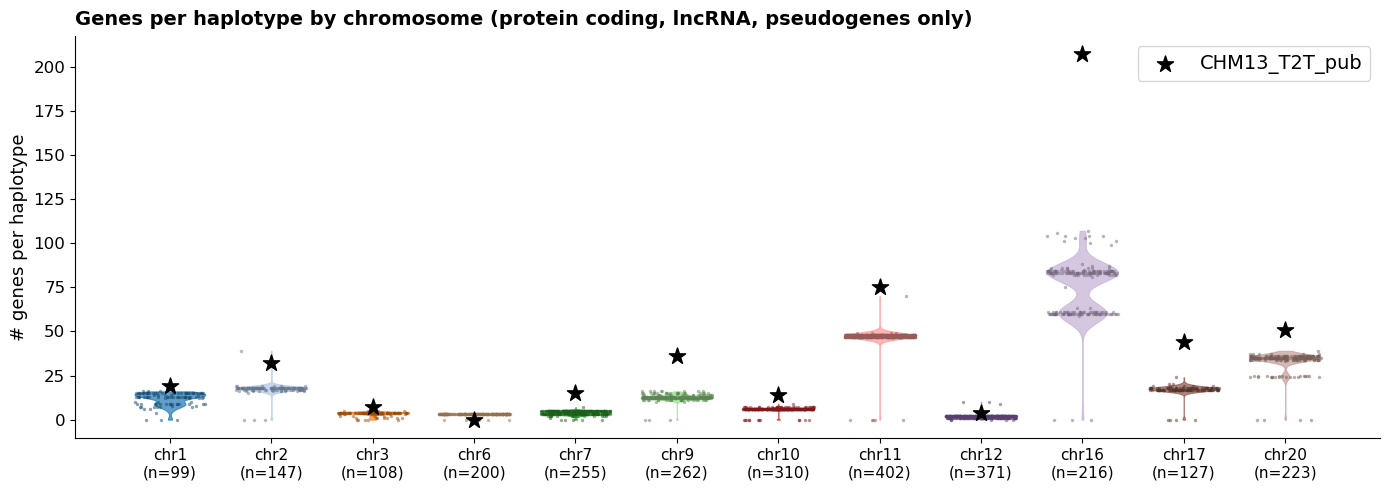

In [45]:
### Num of genes per haplotype plots, dropping acrocrentrics and highlighting CHM13 genes 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

# Apply between_satellites_100kb filter
annot_between = annot_df_filtered[
    annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE', 'True', 1])
].copy()

# ── full grid: per-chrom QC-passing haplotypes from regions_df ────────────────
qc_pass = regions_df[
    (regions_df['pass_qc'] == True) &
    (regions_df['haplotype'] != 0)   # exclude CHM13
][['sample_id', 'haplotype', 'chrom']].copy()
qc_pass['haplotype'] = qc_pass['haplotype'].astype(str)
full_grid = qc_pass[qc_pass['chrom'].isin(CHROM_ORDER)].drop_duplicates()

raw_counts = (
    annot_between.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)
per_hap_chrom = full_grid.merge(raw_counts, on=['sample_id', 'haplotype', 'chrom'], how='left')
per_hap_chrom['count'] = per_hap_chrom['count'].fillna(0).astype(int)

# Keep chroms where ≥20 samples have nonzero count; zero-count samples still plotted
nonzero_n = per_hap_chrom[per_hap_chrom['count'] > 0].groupby('chrom').size()
CHROM_ORDER = [c for c in CHROM_ORDER if nonzero_n.get(c, 0) >= 20]
per_hap_chrom = per_hap_chrom[per_hap_chrom['chrom'].isin(CHROM_ORDER)]

# ── CHM13 counts from genes_df ────────────────────────────────────────────────
chm13_counts = (
    genes_df[
        (genes_df["gene_biotype"].isin(["protein_coding", "lncRNA"]) |
         genes_df["gene_biotype"].str.contains("pseudogene", na=False)) &
        (genes_df["between_satellites_nonacro"].isin([True, "True", "TRUE", 1]))
    ]
    .groupby("chrom")
    .size()
    .to_dict()
)

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title,
                      color_map=None, default_color="#4E72A7", chm13_counts=None):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

        # CHM13 star — always plot, 0 if no passing genes on this chrom
        if chm13_counts is not None:
            ax.scatter([xi], [chm13_counts.get(cat, 0)],
                       marker='*', color='black', s=150, zorder=8,
                       label='_nolegend_')

    # Single legend entry for the star
    if chm13_counts is not None:
        ax.scatter([], [], marker='*', color='black', s=150, label='CHM13_T2T_pub')
        ax.legend(fontsize=14, frameon=True)

    ax.set_xticks(range(len(valid)))
    xlabels = [f"{cat}\n(n={len(data[data[x_col]==cat])})" for cat in valid]
    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 5))

make_violin_panel(ax, per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (protein coding, lncRNA, pseudogenes only)",
                  color_map=chrom_colors,
                  chm13_counts=chm13_counts)

plt.tight_layout()
plt.show()


In [38]:
ens_genes = genes_df[genes_df['name'].str.startswith('ENS', na=False)]
print(f"Total ENS genes in genes_df: {len(ens_genes)}")
print(f"Passing between_satellites_nonacro filter: {len(ens_genes[ens_genes['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])])}")
print(ens_genes['gene_biotype'].value_counts())


Total ENS genes in genes_df: 4
Passing between_satellites_nonacro filter: 0
gene_biotype
processed_pseudogene    3
protein_coding          1
Name: count, dtype: int64


In [50]:
annot_between = annot_df_filtered[
    annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE', 'True', 1])
].copy()

annot_between.to_csv('/private/groups/patenlab/mira/HPRC_censat_genes_btw_satellites_100kb_filtered.csv', index=False)
print(f"Written {len(annot_between):,} rows to CSV")
print(annot_between.columns.tolist())



Written 58,082 rows to CSV
['sample_id', 'haplotype', 'chrom', 'contig', 'start', 'end', 'strand', 'gene_name', 'gene_biotype', 'between_satellites_100kb', 'on_acrocentric_short_arm']


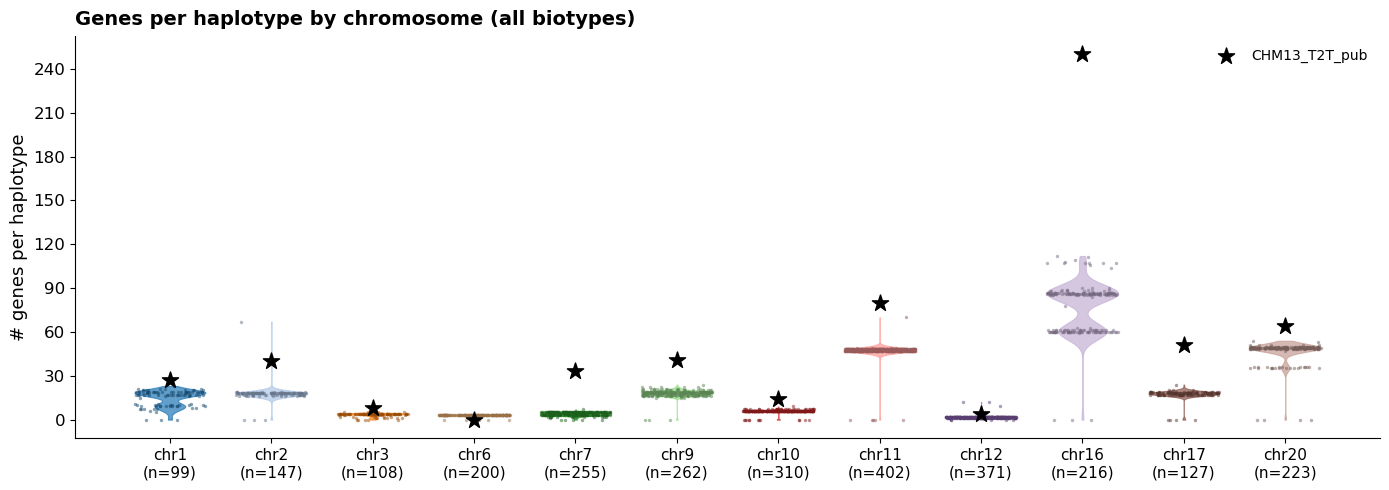

In [35]:
### Num of genes per haplotype plots, dropping acrocrentrics and highlighting CHM13 genes 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

# Apply between_satellites_100kb filter — all biotypes
annot_between = annot_df[
    annot_df['between_satellites_100kb'].isin([True, 'TRUE', 'True', 1])
].copy()

# ── full grid: per-chrom QC-passing haplotypes from regions_df ────────────────
qc_pass = regions_df[
    (regions_df['pass_qc'] == True) &
    (regions_df['haplotype'] != 0)   # exclude CHM13
][['sample_id', 'haplotype', 'chrom']].copy()
qc_pass['haplotype'] = qc_pass['haplotype'].astype(str)
full_grid = qc_pass[qc_pass['chrom'].isin(CHROM_ORDER)].drop_duplicates()

raw_counts = (
    annot_between.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)
per_hap_chrom = full_grid.merge(raw_counts, on=['sample_id', 'haplotype', 'chrom'], how='left')
per_hap_chrom['count'] = per_hap_chrom['count'].fillna(0).astype(int)

# Keep chroms where ≥20 samples have nonzero count; zero-count samples still plotted
nonzero_n = per_hap_chrom[per_hap_chrom['count'] > 0].groupby('chrom').size()
CHROM_ORDER = [c for c in CHROM_ORDER if nonzero_n.get(c, 0) >= 20]
per_hap_chrom = per_hap_chrom[per_hap_chrom['chrom'].isin(CHROM_ORDER)]

# ── CHM13 counts from genes_df — all biotypes, between_satellites_nonacro only ─
chm13_counts = (
    genes_df[
        genes_df["between_satellites_nonacro"].isin([True, "True", "TRUE", 1])
    ]
    .groupby("chrom")
    .size()
    .to_dict()
)

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title,
                      color_map=None, default_color="#4E72A7", chm13_counts=None):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

        # CHM13 star — always plot, 0 if no passing genes on this chrom
        if chm13_counts is not None:
            ax.scatter([xi], [chm13_counts.get(cat, 0)],
                       marker='*', color='black', s=150, zorder=8,
                       label='_nolegend_')

    # Single legend entry for the star
    if chm13_counts is not None:
        ax.scatter([], [], marker='*', color='black', s=150, label='CHM13_T2T_pub')
        ax.legend(fontsize=10, frameon=False)

    ax.set_xticks(range(len(valid)))
    xlabels = [f"{cat}\n(n={len(data[data[x_col]==cat])})" for cat in valid]
    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 5))

make_violin_panel(ax, per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (all biotypes)",
                  color_map=chrom_colors,
                  chm13_counts=chm13_counts)

plt.tight_layout()
plt.show()



In [47]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.collections import PatchCollection

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CHM13_BED      = f'{CENSAT_BED_DIR}/chm13v2.0_censat_v2.1.bed'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_with_genes_filtered.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55
GENE_TICK_H    = 0.30
GENE_GAP       = 0.05
MAX_HAPS       = 50

# ── pre-index HPRC genes (filtered biotypes + between_satellites_100kb) ────────
between_true = annot_df_filtered[
    annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE'])
].copy()
gene_lookup = {key: grp for key, grp in
               between_true.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── CHM13 genes from genes_df ─────────────────────────────────────────────────
chm13_genes = genes_df[
    (genes_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
     genes_df['gene_biotype'].str.contains('pseudogene', na=False)) &
    genes_df['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])
].copy()

# ── build bed_map (HPRC samples) ──────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path
print(f"bed_map entries: {len(bed_map_v4)}")

# ── pre-load HPRC BED files ───────────────────────────────────────────────────
print("Pre-loading HPRC censat BED files...", flush=True)
censat_cache = {}
for (sid, hap), bed_path in bed_map_v4.items():
    seq_data = {}
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            seq = s_parts[2] if len(s_parts) == 3 else cols[0].strip()
            start, end = int(cols[1]), int(cols[2])
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            seq_data.setdefault(seq, []).append((start, end, color))
    censat_cache[(sid, hap)] = seq_data
print(f"Loaded {len(censat_cache)} HPRC samples", flush=True)

# ── pre-load CHM13 BED ────────────────────────────────────────────────────────
print("Pre-loading CHM13 BED...", flush=True)
chm13_cache = {}  # chrom -> [(start, end, color)]
with open(CHM13_BED) as f:
    for line in f:
        if line.startswith('track'): continue
        cols = line.split('\t')
        if len(cols) < 9: continue
        seq = cols[0].strip()
        start, end = int(cols[1]), int(cols[2])
        try:    color = tuple(int(x)/255 for x in cols[8].split(','))
        except: color = (0.5, 0.5, 0.5)
        chm13_cache.setdefault(seq, []).append((start, end, color))
print(f"CHM13 BED loaded — {len(chm13_cache)} chroms", flush=True)

# ── one page per chrom ────────────────────────────────────────────────────────
np.random.seed(42)

with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:

        # CHM13 region — bounds from chm13_cache
        chm13_segs = chm13_cache.get(chrom, [])
        has_chm13  = len(chm13_segs) > 0
        if has_chm13:
            chm13_rs = min(s for s, e, c in chm13_segs)
            chm13_re = max(e for s, e, c in chm13_segs)
            print(f"  CHM13 {chrom}: {len(chm13_segs)} segs  {chm13_rs:,}–{chm13_re:,}", flush=True)

        # HPRC regions
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) &
            (regions_df['pass_qc'] == True) &
            (regions_df['haplotype'] != 0)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: (r['sample_id'], r['haplotype']) in censat_cache, axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0 and not has_chm13:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        if len(chrom_regions) > MAX_HAPS:
            chrom_regions = chrom_regions.sample(n=MAX_HAPS, random_state=42).reset_index(drop=True)

        n_hprc = len(chrom_regions)
        n_rows = n_hprc + (1 if has_chm13 else 0)

        sizes = (chrom_regions['region_end'] - chrom_regions['region_start']).tolist()
        if has_chm13:
            sizes.append(chm13_re - chm13_rs)
        max_size_mbp = max(sizes) / 1e6 if sizes else 1.0

        print(f"{chrom}: CHM13={'yes' if has_chm13 else 'no'}  HPRC={n_hprc}  max={max_size_mbp:.2f}Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n_rows * ROW_H + 1.5))
        all_patches = []
        all_colors  = []

        # ── CHM13 row (yi=0, top) ─────────────────────────────────────────────
        if has_chm13:
            rs  = chm13_rs
            re_ = chm13_re

            # light background band for CHM13 row
            ax.axhspan(-1, 0.5, facecolor='#fffbe6', alpha=0.6, zorder=0)

            for start, end, color in chm13_segs:
                if end < rs or start > re_: continue
                x0 = (max(start, rs) - rs) / 1e6
                x1 = (min(end,   re_) - rs) / 1e6
                all_patches.append(mpatches.Rectangle((x0, -CSAT_H/2), x1 - x0, CSAT_H))
                all_colors.append(color)

            # CHM13 gene ticks
            cg_in = chm13_genes[
                (chm13_genes['chrom'] == chrom) &
                (chm13_genes['end']   >= rs) &
                (chm13_genes['start'] <= re_)
            ]
            if len(cg_in):
                bar_top  = -CSAT_H/2
                tick_bot = bar_top - GENE_GAP
                tick_top = tick_bot - GENE_TICK_H
                mids = ((cg_in['start'] + cg_in['end']) / 2 - rs) / 1e6
                ax.vlines(mids.values, tick_top, tick_bot, colors='#333333', lw=0.8)

            # Label — clip_on=False so text outside xlim is visible
            ax.text(0, 0, 'CHM13', ha='right', va='center',
                    fontsize=7, fontweight='bold', color='#8B0000',
                    clip_on=False, transform=ax.transData)

        # ── HPRC rows ─────────────────────────────────────────────────────────
        for yi_offset, (_, row) in enumerate(chrom_regions.iterrows()):
            yi  = yi_offset + (1 if has_chm13 else 0)
            sid, hap = row['sample_id'], row['haplotype']
            rs,  re_ = row['region_start'], row['region_end']
            seq      = row['sequence_id'].split('#')[-1]

            for start, end, color in censat_cache.get((sid, hap), {}).get(seq, []):
                if end < rs or start > re_: continue
                x0 = (max(start, rs) - rs) / 1e6
                x1 = (min(end,   re_) - rs) / 1e6
                all_patches.append(mpatches.Rectangle((x0, yi - CSAT_H/2), x1 - x0, CSAT_H))
                all_colors.append(color)

            genes = gene_lookup.get((sid, hap, chrom))
            if genes is not None:
                in_region = genes[
                    (genes['contig'] == seq) &
                    (genes['end']   >= rs)   &
                    (genes['start'] <= re_)
                ]
                if len(in_region):
                    bar_top  = yi - CSAT_H/2
                    tick_bot = bar_top - GENE_GAP
                    tick_top = tick_bot - GENE_TICK_H
                    mids = ((in_region['start'] + in_region['end']) / 2 - rs) / 1e6
                    ax.vlines(mids.values, tick_top, tick_bot, colors='#333333', lw=0.8)

        if all_patches:
            ax.add_collection(PatchCollection(all_patches, facecolors=all_colors, linewidths=0))

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n_rows)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(
            f"{chrom} — CHM13 + {n_hprc} HPRC haplotypes (max {MAX_HAPS} subsampled)",
            fontsize=13, fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
Pre-loading HPRC censat BED files...


Loaded 462 HPRC samples
Pre-loading CHM13 BED...
CHM13 BED loaded — 24 chroms
  CHM13 chr1: 80 segs  116,796,047–147,241,659
chr1: CHM13=yes  HPRC=50  max=30.45Mbp
  CHM13 chr2: 100 segs  85,991,677–99,673,021
chr2: CHM13=yes  HPRC=50  max=13.68Mbp
  CHM13 chr3: 30 segs  85,804,701–101,415,026
chr3: CHM13=yes  HPRC=50  max=15.61Mbp
  CHM13 chr4: 43 segs  44,705,153–59,870,510
chr4: CHM13=yes  HPRC=50  max=15.17Mbp
  CHM13 chr5: 29 segs  42,077,201–54,596,624
chr5: CHM13=yes  HPRC=50  max=12.52Mbp
  CHM13 chr6: 17 segs  53,286,688–66,058,390
chr6: CHM13=yes  HPRC=50  max=12.77Mbp
  CHM13 chr7: 135 segs  55,414,371–68,714,499
chr7: CHM13=yes  HPRC=50  max=13.30Mbp
  CHM13 chr8: 56 segs  39,243,545–51,325,080
chr8: CHM13=yes  HPRC=50  max=12.08Mbp
  CHM13 chr9: 170 segs  39,952,797–81,694,041
chr9: CHM13=yes  HPRC=50  max=41.74Mbp
  CHM13 chr10: 47 segs  34,633,793–46,664,589
chr10: CHM13=yes  HPRC=50  max=12.03Mbp
  CHM13 chr11: 23 segs  46,061,947–59,413,484
chr11: CHM13=yes  HPRC=50  m

In [53]:
## expanded view 

import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.collections import PatchCollection

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CHM13_BED      = f'{CENSAT_BED_DIR}/chm13v2.0_censat_v2.1.bed'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_with_genes_filtered_500kb.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.55
GENE_TICK_H    = 0.30
GENE_GAP       = 0.05
MAX_HAPS       = 50
FLANK = 3_000_000  # bp to extend display on each side of array bounds

# ── pre-index HPRC genes (filtered biotypes + between_satellites_100kb) ────────
between_true = annot_df_filtered[
    annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE'])
].copy()
gene_lookup = {key: grp for key, grp in
               between_true.groupby(['sample_id', 'haplotype', 'chrom'])}

# ── CHM13 genes from genes_df ─────────────────────────────────────────────────
chm13_genes = genes_df[
    (genes_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
     genes_df['gene_biotype'].str.contains('pseudogene', na=False)) &
    genes_df['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])
].copy()

# ── build bed_map (HPRC samples) ──────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path
print(f"bed_map entries: {len(bed_map_v4)}")

# ── pre-load HPRC BED files ───────────────────────────────────────────────────
print("Pre-loading HPRC censat BED files...", flush=True)
censat_cache = {}
for (sid, hap), bed_path in bed_map_v4.items():
    seq_data = {}
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            seq = s_parts[2] if len(s_parts) == 3 else cols[0].strip()
            start, end = int(cols[1]), int(cols[2])
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            seq_data.setdefault(seq, []).append((start, end, color))
    censat_cache[(sid, hap)] = seq_data
print(f"Loaded {len(censat_cache)} HPRC samples", flush=True)

# ── pre-load CHM13 BED ────────────────────────────────────────────────────────
print("Pre-loading CHM13 BED...", flush=True)
chm13_cache = {}
with open(CHM13_BED) as f:
    for line in f:
        if line.startswith('track'): continue
        cols = line.split('\t')
        if len(cols) < 9: continue
        seq = cols[0].strip()
        start, end = int(cols[1]), int(cols[2])
        try:    color = tuple(int(x)/255 for x in cols[8].split(','))
        except: color = (0.5, 0.5, 0.5)
        chm13_cache.setdefault(seq, []).append((start, end, color))
print(f"CHM13 BED loaded — {len(chm13_cache)} chroms", flush=True)

# ── one page per chrom ────────────────────────────────────────────────────────
np.random.seed(42)

with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:

        # CHM13 region — extend by FLANK
        chm13_segs = chm13_cache.get(chrom, [])
        has_chm13  = len(chm13_segs) > 0
        if has_chm13:
            chm13_rs_orig = min(s for s, e, c in chm13_segs)
            chm13_re_orig = max(e for s, e, c in chm13_segs)
            chm13_rs = max(0, chm13_rs_orig - FLANK)
            chm13_re = chm13_re_orig + FLANK

        # HPRC regions
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) &
            (regions_df['pass_qc'] == True) &
            (regions_df['haplotype'] != 0)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: (r['sample_id'], r['haplotype']) in censat_cache, axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0 and not has_chm13:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        if len(chrom_regions) > MAX_HAPS:
            chrom_regions = chrom_regions.sample(n=MAX_HAPS, random_state=42).reset_index(drop=True)

        n_hprc = len(chrom_regions)
        n_rows = n_hprc + (1 if has_chm13 else 0)

        # max display size including flanks
        sizes = [(row['region_end'] + FLANK - max(0, row['region_start'] - FLANK))
                 for _, row in chrom_regions.iterrows()]
        if has_chm13:
            sizes.append(chm13_re - chm13_rs)
        max_size_mbp = max(sizes) / 1e6 if sizes else 1.0

        print(f"{chrom}: CHM13={'yes' if has_chm13 else 'no'}  HPRC={n_hprc}  max={max_size_mbp:.2f}Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n_rows * ROW_H + 1.5))
        all_patches = []
        all_colors  = []

        # ── CHM13 row (yi=0, top) ─────────────────────────────────────────────
        if has_chm13:
            rs, re_ = chm13_rs, chm13_re
            ax.axhspan(-1, 0.5, facecolor='#fffbe6', alpha=0.6, zorder=0)

            for start, end, color in chm13_segs:
                if end < rs or start > re_: continue
                x0 = (max(start, rs) - rs) / 1e6
                x1 = (min(end,   re_) - rs) / 1e6
                all_patches.append(mpatches.Rectangle((x0, -CSAT_H/2), x1 - x0, CSAT_H))
                all_colors.append(color)

            cg_in = chm13_genes[
                (chm13_genes['chrom'] == chrom) &
                (chm13_genes['end']   >= rs) &
                (chm13_genes['start'] <= re_)
            ]
            if len(cg_in):
                bar_top  = -CSAT_H/2
                tick_bot = bar_top - GENE_GAP
                tick_top = tick_bot - GENE_TICK_H
                mids = ((cg_in['start'] + cg_in['end']) / 2 - rs) / 1e6
                ax.vlines(mids.values, tick_top, tick_bot, colors='#333333', lw=0.8, zorder=9)

            ax.text(0, 0, 'CHM13', ha='right', va='center',
                    fontsize=7, fontweight='bold', color='#8B0000',
                    clip_on=False, transform=ax.transData)

        # ── HPRC rows ─────────────────────────────────────────────────────────
        for yi_offset, (_, row) in enumerate(chrom_regions.iterrows()):
            yi       = yi_offset + (1 if has_chm13 else 0)
            sid, hap = row['sample_id'], row['haplotype']
            rs_orig  = row['region_start']
            re_orig  = row['region_end']
            rs       = max(0, rs_orig - FLANK)   # extended window
            re_      = re_orig + FLANK
            seq      = row['sequence_id'].split('#')[-1]

            for start, end, color in censat_cache.get((sid, hap), {}).get(seq, []):
                if end < rs or start > re_: continue
                x0 = (max(start, rs) - rs) / 1e6
                x1 = (min(end,   re_) - rs) / 1e6
                all_patches.append(mpatches.Rectangle((x0, yi - CSAT_H/2), x1 - x0, CSAT_H))
                all_colors.append(color)

            genes = gene_lookup.get((sid, hap, chrom))
            if genes is not None:
                in_region = genes[
                    (genes['contig'] == seq) &
                    (genes['end']   >= rs)   &
                    (genes['start'] <= re_)
                ]
                if len(in_region):
                    bar_top  = yi - CSAT_H/2
                    tick_bot = bar_top - GENE_GAP
                    tick_top = tick_bot - GENE_TICK_H
                    mids = ((in_region['start'] + in_region['end']) / 2 - rs) / 1e6
                    ax.vlines(mids.values, tick_top, tick_bot, colors='#333333', lw=0.8, zorder=9)

        if all_patches:
            ax.add_collection(PatchCollection(all_patches, facecolors=all_colors, linewidths=0))


        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n_rows)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp, ±3Mbp flanks shown)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(
            f"{chrom} — CHM13 + {n_hprc} HPRC haplotypes (max {MAX_HAPS} subsampled, ±500kb flanks)",
            fontsize=13, fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")


bed_map entries: 462
Pre-loading HPRC censat BED files...
Loaded 462 HPRC samples
Pre-loading CHM13 BED...
CHM13 BED loaded — 24 chroms
chr1: CHM13=yes  HPRC=50  max=36.45Mbp
chr2: CHM13=yes  HPRC=50  max=19.68Mbp
chr3: CHM13=yes  HPRC=50  max=21.61Mbp
chr4: CHM13=yes  HPRC=50  max=21.17Mbp
chr5: CHM13=yes  HPRC=50  max=18.52Mbp
chr6: CHM13=yes  HPRC=50  max=18.77Mbp
chr7: CHM13=yes  HPRC=50  max=19.30Mbp
chr8: CHM13=yes  HPRC=50  max=18.08Mbp
chr9: CHM13=yes  HPRC=50  max=47.74Mbp
chr10: CHM13=yes  HPRC=50  max=18.03Mbp
chr11: CHM13=yes  HPRC=50  max=19.35Mbp
chr12: CHM13=yes  HPRC=50  max=18.58Mbp
chr13: CHM13=yes  HPRC=6  max=25.50Mbp
chr14: CHM13=yes  HPRC=16  max=20.71Mbp
chr15: CHM13=yes  HPRC=10  max=25.69Mbp
chr16: CHM13=yes  HPRC=50  max=32.37Mbp
chr17: CHM13=yes  HPRC=50  max=19.59Mbp
chr18: CHM13=yes  HPRC=50  max=20.97Mbp
chr19: CHM13=yes  HPRC=50  max=21.11Mbp
chr20: CHM13=yes  HPRC=50  max=22.59Mbp
chr21: CHM13=yes  HPRC=3  max=19.34Mbp
chr22: CHM13=yes  HPRC=3  max=23.71

In [ ]:
### Debugging CHM13 discrepancies

In [46]:
for chrom in ['chr7', 'chr9', 'chr11', 'chr16', 'chr17', 'chr20']:
    chm13_chrom = genes_df[
        (genes_df['chrom'] == chrom) &
        (genes_df['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])) &
        (genes_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
         genes_df['gene_biotype'].str.contains('pseudogene', na=False))
    ][['name', 'gene_biotype']].copy()

    hprc_names = annot_df_filtered[
        (annot_df_filtered['chrom'] == chrom) &
        (annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE', 'True', 1]))
    ]['gene_name'].unique()

    not_in_hprc = chm13_chrom[~chm13_chrom['name'].isin(hprc_names)]
    print(f"\n{chrom}: {len(chm13_chrom)} CHM13 genes, {len(not_in_hprc)} not in any HPRC sample")
    print(not_in_hprc['gene_biotype'].value_counts().to_string())



chr7: 15 CHM13 genes, 10 not in any HPRC sample
gene_biotype
lncRNA                  6
processed_pseudogene    4

chr9: 36 CHM13 genes, 27 not in any HPRC sample
gene_biotype
processed_pseudogene      12
lncRNA                    12
unprocessed_pseudogene     2
protein_coding             1

chr11: 75 CHM13 genes, 38 not in any HPRC sample
gene_biotype
unprocessed_pseudogene                17
processed_pseudogene                  10
transcribed_unprocessed_pseudogene     7
lncRNA                                 3
protein_coding                         1

chr16: 207 CHM13 genes, 106 not in any HPRC sample
gene_biotype
lncRNA                                49
processed_pseudogene                  32
unprocessed_pseudogene                18
transcribed_unprocessed_pseudogene     4
transcribed_processed_pseudogene       2
protein_coding                         1

chr17: 44 CHM13 genes, 29 not in any HPRC sample
gene_biotype
lncRNA                              10
unprocessed_pseudogene     

In [ ]:
# chr16 after filtering 

# CHM13 chr16 passing genes
chm13_chr16 = genes_df[
    (genes_df['chrom'] == 'chr16') &
    (genes_df['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])) &
    (genes_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
     genes_df['gene_biotype'].str.contains('pseudogene', na=False))
][['name', 'gene_biotype', 'start', 'end']].copy()

# HPRC chr16 passing genes — unique gene names seen across samples
hprc_chr16 = annot_df_filtered[
    (annot_df_filtered['chrom'] == 'chr16') &
    (annot_df_filtered['between_satellites_100kb'].isin([True, 'TRUE', 'True', 1]))
]['gene_name'].unique()

# Genes in CHM13 but not in any HPRC sample
chm13_chr16['in_hprc'] = chm13_chr16['name'].isin(hprc_chr16)

print(f"CHM13 chr16 passing genes: {len(chm13_chr16)}")
print(f"HPRC chr16 unique passing gene names: {len(hprc_chr16)}")
print(f"\nIn CHM13 but NOT in any HPRC sample:")
print(chm13_chr16[~chm13_chr16['in_hprc']][['name', 'gene_biotype', 'start', 'end']].to_string())
print(f"\nIn both CHM13 and HPRC:")
print(chm13_chr16[chm13_chr16['in_hprc']][['name', 'gene_biotype', 'start', 'end']].to_string())

CHM13 chr16 passing genes: 207
HPRC chr16 unique passing gene names: 132

In CHM13 but NOT in any HPRC sample:
             name                        gene_biotype     start       end
21168  AC137800.1  transcribed_unprocessed_pseudogene  33014729  33030069
21169  AC137800.2              unprocessed_pseudogene  33033163  33036614
21170  AC141257.2                              lncRNA  33064600  33078412
21171  AC138869.3                              lncRNA  33078381  33080989
21173  AC138869.2                              lncRNA  33089493  33093287
21174  AC138869.1                processed_pseudogene  33130371  33130494
21176  AC145350.4                              lncRNA  33150346  33155532
21177  AC145350.1                processed_pseudogene  33154406  33154613
21179  AC145350.2                              lncRNA  33189404  33241067
21180  AC145350.3                processed_pseudogene  33224735  33224897
21181  AC142086.5    transcribed_processed_pseudogene  33256642  33332678
2

In [ ]:
not_in_hprc = chm13_chr16[~chm13_chr16['in_hprc']]
print(f"CHM13 chr16 genes not in any HPRC sample: {len(not_in_hprc)}")
print(not_in_hprc['gene_biotype'].value_counts())


CHM13 chr16 genes not in any HPRC sample: 106
gene_biotype
lncRNA                                49
processed_pseudogene                  32
unprocessed_pseudogene                18
transcribed_unprocessed_pseudogene     4
transcribed_processed_pseudogene       2
protein_coding                         1
Name: count, dtype: int64


In [31]:
sub = genes_df[
    (genes_df['chrom'] == 'chr16') &
    (genes_df['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])) &
    (genes_df['gene_biotype'].isin(['protein_coding', 'lncRNA']) |
     genes_df['gene_biotype'].str.contains('pseudogene', na=False))
]
print(sub['gene_biotype'].value_counts())
print(f"\nTotal: {len(sub)}")
print(sub[['name', 'gene_biotype', 'chrom', 'start', 'end']].to_string())


gene_biotype
processed_pseudogene                  65
lncRNA                                54
unprocessed_pseudogene                35
rRNA_pseudogene                       19
transcribed_unprocessed_pseudogene    13
IG_V_pseudogene                       12
protein_coding                         5
transcribed_processed_pseudogene       4
Name: count, dtype: int64

Total: 207
               name                        gene_biotype  chrom     start       end
21168    AC137800.1  transcribed_unprocessed_pseudogene  chr16  33014729  33030069
21169    AC137800.2              unprocessed_pseudogene  chr16  33033163  33036614
21170    AC141257.2                              lncRNA  chr16  33064600  33078412
21171    AC138869.3                              lncRNA  chr16  33078381  33080989
21172      TP53TG3C                      protein_coding  chr16  33087984  33090583
21173    AC138869.2                              lncRNA  chr16  33089493  33093287
21174    AC138869.1                proce

In [26]:
for chrom in ['chr4', 'chr6', 'chr18', 'chr19']:
    sub = genes_df[genes_df['chrom'] == chrom]
    total = len(sub)
    biotype_ok = sub['gene_biotype'].isin(['protein_coding', 'lncRNA']) | sub['gene_biotype'].str.contains('pseudogene', na=False)
    between_ok = sub['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])
    passing = len(sub[biotype_ok & between_ok])
    print(f"{chrom}: {total} total genes, {passing} passing filter")



chr4: 2699 total genes, 0 passing filter
chr6: 3073 total genes, 0 passing filter
chr18: 1264 total genes, 0 passing filter
chr19: 2995 total genes, 0 passing filter


In [28]:
for chrom in ['chr4', 'chr6', 'chr18', 'chr19']:
    sub = genes_df[genes_df['chrom'] == chrom]
    biotype_ok = sub['gene_biotype'].isin(['protein_coding', 'lncRNA']) | sub['gene_biotype'].str.contains('pseudogene', na=False)
    between_ok = sub['between_satellites_nonacro'].isin([True, 'True', 'TRUE', 1])
    
    n_biotype_fail   = (~biotype_ok).sum()
    n_between_fail   = (biotype_ok & ~between_ok).sum()
    n_both_fail      = (~biotype_ok & ~between_ok).sum()
    n_pass           = (biotype_ok & between_ok).sum()
    
    print(f"{chrom}: total={len(sub)}  pass={n_pass}  "
          f"fail_biotype_only={n_biotype_fail - n_both_fail}  "
          f"fail_between_only={n_between_fail}  "
          f"fail_both={n_both_fail}")
    print(f"  between_satellites_nonacro unique values: {sub['between_satellites_nonacro'].unique()}")



chr4: total=2699  pass=0  fail_biotype_only=0  fail_between_only=2333  fail_both=366
  between_satellites_nonacro unique values: [False]
chr6: total=3073  pass=0  fail_biotype_only=0  fail_between_only=2714  fail_both=359
  between_satellites_nonacro unique values: [False]
chr18: total=1264  pass=0  fail_biotype_only=0  fail_between_only=1071  fail_both=193
  between_satellites_nonacro unique values: [False]
chr19: total=2995  pass=0  fail_biotype_only=0  fail_between_only=2669  fail_both=326
  between_satellites_nonacro unique values: [False]


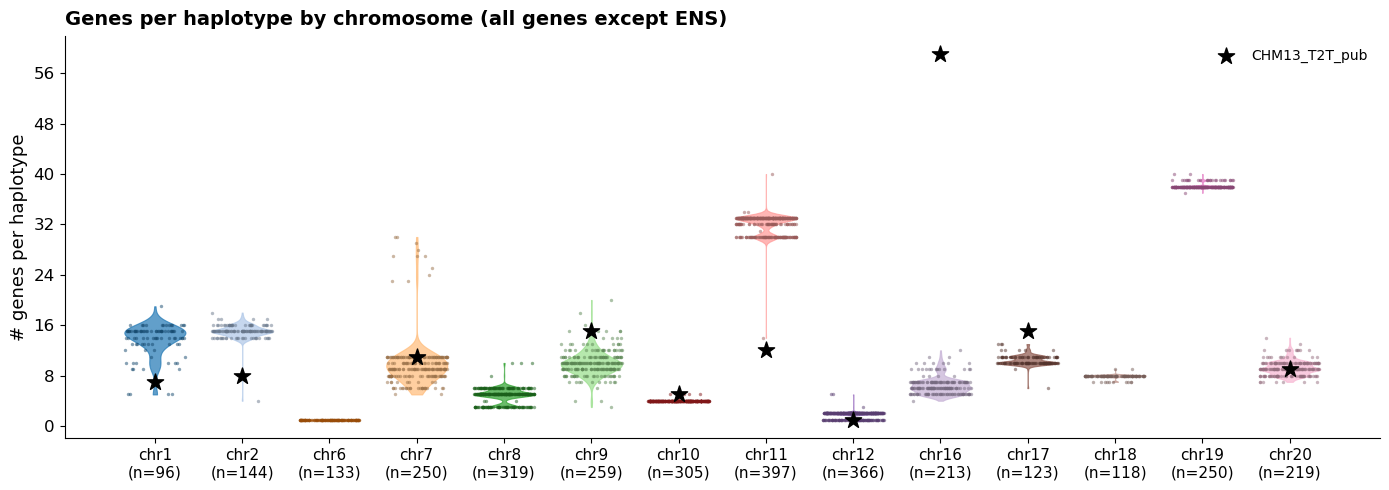

In [20]:
### Num of genes per haplotype plots, dropping acrocrentrics and highlighting CHM13 genes 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

annot_pc_lnc = annot_df[
    annot_df["gene_biotype"].isin(["protein_coding", "lncRNA"])
].copy()

per_hap_chrom = (
    annot_pc_lnc.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)

chrom_n = per_hap_chrom.groupby("chrom").size()
CHROM_ORDER = [c for c in CHROM_ORDER if chrom_n.get(c, 0) >= 20]

# ── CHM13 counts from genes_df ────────────────────────────────────────────────
chm13_counts = (
    genes_df[
        genes_df["gene_biotype"].isin(["protein_coding", "lncRNA"]) &
        (genes_df["between_satellites_nonacro"].isin([True, "True", "TRUE", 1]))
    ]
    .groupby("chrom")
    .size()
    .to_dict()
)

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title,
                      color_map=None, default_color="#4E72A7", chm13_counts=None):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

        # CHM13 star
        if chm13_counts is not None and cat in chm13_counts:
            ax.scatter([xi], [chm13_counts[cat]],
                       marker='*', color='black', s=150, zorder=8,
                       label='_nolegend_')

    # Single legend entry for the star
    if chm13_counts is not None:
        ax.scatter([], [], marker='*', color='black', s=150, label='CHM13_T2T_pub')
        ax.legend(fontsize=10, frameon=False)

    ax.set_xticks(range(len(valid)))
    xlabels = [f"{cat}\n(n={len(data[data[x_col]==cat])})" for cat in valid]
    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 5))

make_violin_panel(ax, per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (all genes except ENS)",
                  color_map=chrom_colors,
                  chm13_counts=chm13_counts)

plt.tight_layout()
plt.show()


### Debugging / spot checking

In [37]:
# ── Step 1: find a sample with 5 copies of LINC02799 on chr7 ─────────────────
linc_chr7 = annot_df[
    (annot_df['gene_name'] == 'LINC02799') &
    (annot_df['chrom'] == 'chr7')
]

copy_counts = (
    linc_chr7
    .groupby(['sample_id', 'haplotype'])
    .size()
    .reset_index(name='n_copies')
    .sort_values('n_copies', ascending=False)
)
print(copy_counts.head(10))

# pick one sample with 5 copies
target = copy_counts[copy_counts['n_copies'] == 5].iloc[0]
sid, hap = target['sample_id'], target['haplotype']
print(f"\nUsing: {sid}  hap={hap}")

# ── Step 2: show all LINC02799 entries for that sample with filter status ──────
sample_linc = linc_chr7[
    (linc_chr7['sample_id'] == sid) &
    (linc_chr7['haplotype'] == hap)
][['contig', 'start', 'end', 'gene_name', 'between_satellites_100kb', 'on_acrocentric_short_arm']]
print("\nLINC02799 entries:")
display(sample_linc)

# ── Step 3: look at raw censat blocks around each filtered-out gene ────────────
import re

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'

def load_blocks_around(sid, hap, contig, gene_start, gene_end, window_bp=500_000):
    bed_path = bed_map_v4.get((sid, hap))
    if bed_path is None:
        print("No BED found"); return
    seq = contig  # gene TSV contigs are already plain names
    lo, hi = gene_start - window_bp, gene_end + window_bp
    blocks = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[-1]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < lo or start > hi: continue
            blocks.append({'start': start, 'end': end,
                           'size_kb': (end-start)/1e3, 'name': cols[3]})
    return pd.DataFrame(blocks)

print("\nCenSat blocks ±500kb around each LINC02799 gene:")
for _, g in sample_linc.iterrows():
    print(f"\n  gene: {g['start']:,} – {g['end']:,}  between_sat={g['between_satellites_100kb']}")
    df = load_blocks_around(sid, str(hap), g['contig'], g['start'], g['end'])
    if df is not None and len(df):
        display(df.to_string(index=False))


   sample_id haplotype  n_copies
1    HG00126         1         5
2    HG00128         1         5
8    HG00146         2         5
5    HG00133         2         5
17   HG00323         1         5
16   HG00321         2         5
14   HG00320         1         5
15   HG00321         1         5
12   HG00280         1         5
11   HG00272         1         5

Using: HG00126  hap=1

LINC02799 entries:


,contig,start,end,gene_name,between_satellites_100kb,on_acrocentric_short_arm
168640,CM090113.1,58606884,58608195,LINC02799,False,False
168641,CM090113.1,58647712,58649032,LINC02799,False,False
168642,CM090113.1,59182328,59183647,LINC02799,False,False
168643,CM090113.1,59306629,59307950,LINC02799,False,False
168644,CM090113.1,59984967,59986289,LINC02799,False,False



CenSat blocks ±500kb around each LINC02799 gene:

  gene: 58,606,884 – 58,608,195  between_sat=False


'   start      end  size_kb          name\n58106680 58162408   55.728            ct\n58162408 58305661  143.253           mon\n58305661 58310942    5.281 dhor(S5C1H5d)\n58310942 58314135    3.193 dhor(S2CMH4d)\n58314135 58349536   35.401         HSat2\n58349536 58385747   36.211            ct\n58385747 58401000   15.253         HSat2\n58401000 58593520  192.520         HSat3\n58593520 58705891  112.371            ct\n58705891 58732575   26.684         HSat2\n58732575 58855997  123.422         HSat3\n58855997 58869016   13.019         HSat2\n58869016 58960711   91.695            ct\n58960711 58973984   13.273         HSat2\n58973984 59098772  124.788         HSat3\n59098772 59125458   26.686         HSat2'


  gene: 58,647,712 – 58,649,032  between_sat=False


...

'   start      end  size_kb        name\n58593520 58705891  112.371          ct\n58705891 58732575   26.684       HSat2\n58732575 58855997  123.422       HSat3\n58855997 58869016   13.019       HSat2\n58869016 58960711   91.695          ct\n58960711 58973984   13.273       HSat2\n58973984 59098772  124.788       HSat3\n59098772 59125458   26.686       HSat2\n59125458 59209638   84.180          ct\n59209638 59212008    2.370       HSat2\n59212008 59252331   40.323       HSat2\n59252331 59280287   27.956          ct\n59280287 59286444    6.157       HSat2\n59286444 59288334    1.890       HSat2\n59288334 59331246   42.912          ct\n59331246 59351661   20.415       HSat2\n59351661 59377798   26.137          ct\n59377798 59401409   23.611       HSat2\n59401409 59444026   42.617          ct\n59444026 59668891  224.865         mon\n59668891 59862669  193.778 hor(S5C7H2)'


  gene: 59,306,629 – 59,307,950  between_sat=False


'   start      end  size_kb        name\n58732575 58855997  123.422       HSat3\n58855997 58869016   13.019       HSat2\n58869016 58960711   91.695          ct\n58960711 58973984   13.273       HSat2\n58973984 59098772  124.788       HSat3\n59098772 59125458   26.686       HSat2\n59125458 59209638   84.180          ct\n59209638 59212008    2.370       HSat2\n59212008 59252331   40.323       HSat2\n59252331 59280287   27.956          ct\n59280287 59286444    6.157       HSat2\n59286444 59288334    1.890       HSat2\n59288334 59331246   42.912          ct\n59331246 59351661   20.415       HSat2\n59351661 59377798   26.137          ct\n59377798 59401409   23.611       HSat2\n59401409 59444026   42.617          ct\n59444026 59668891  224.865         mon\n59668891 59862669  193.778 hor(S5C7H2)'


  gene: 59,984,967 – 59,986,289  between_sat=False


'   start      end  size_kb                name\n59444026 59668891  224.865                 mon\n59668891 59862669  193.778         hor(S5C7H2)\n59862669 59874165   11.496                 mon\n59874165 59879790    5.625      dhor(S02CMH2d)\n59879790 59880771    0.981       dhor(S2CMH4d)\n59880771 59903504   22.733                  ct\n59903504 59959886   56.382               HSat2\n59959886 60042583   82.697                  ct\n60042583 60072293   29.710               HSat2\n60072293 60090222   17.929                  ct\n60090222 60459812  369.590                 mon\n60459812 60462690    2.878       dhor(S1CMH3d)\n60462690 63153714 2691.024 active_hor(S1C7H1L)'

In [47]:
import sys
sys.path.insert(0, '/private/groups/patenlab/mira/centrolign/github/centrolign_analysis/analysis_notes/release2_QC_v2/slurm_scripts')

from annotate_satellite_neighbors import parse_bed, merge_nonct_blocks, find_neighbors, dominant_overlap_cat, is_ct

# load and merge blocks for this sample
bed_path = bed_map_v4.get((sid, str(hap)))
raw_blocks, _ = parse_bed(bed_path)

# strip contig prefix to match gene contig name
contig = sample_linc['contig'].iloc[0]
cb_raw    = raw_blocks.get(contig, [])
cb_merged = merge_nonct_blocks(cb_raw)

print(f"Sample: {sid}  hap={hap}  contig={contig}\n")
print(f"{'Copy':>5}  {'start':>12}  {'end':>12}  {'passed':>6}  "
      f"{'left_block':>35}  {'left_kb':>8}  {'right_block':>35}  {'right_kb':>8}")
print("-" * 130)

for i, (_, g) in enumerate(sample_linc.iterrows()):
    gs, ge = int(g['start']), int(g['end'])

    # dominant category (CT check)
    dom = dominant_overlap_cat(cb_merged, gs, ge)

    # find neighbors
    left_size = right_size = None
    left_blk  = right_blk  = None
    best_le, best_rs_ = -1, float('inf')
    for s, e, size, name in cb_merged:
        if e <= gs and e > best_le:
            best_le, left_size, left_blk = e, size, (s, e, name)
        if s >= ge and s < best_rs_:
            best_rs_, right_size, right_blk = s, size, (s, e, name)

    def fmt_blk(blk):
        if blk is None: return "None"
        s, e, name = blk
        return f"{name} [{s:,}–{e:,}]"

    passed = g['between_satellites_100kb']
    print(f"{i+1:>5}  {gs:>12,}  {ge:>12,}  {str(passed):>6}  "
          f"{fmt_blk(left_blk):>35}  "
          f"{left_size/1e3 if left_size else 0:>7.1f}k  "
          f"{fmt_blk(right_blk):>35}  "
          f"{right_size/1e3 if right_size else 0:>7.1f}k")
    print(f"       dominant overlap: {dom}")


Sample: NA20806  hap=1  contig=CM090113.1

 Copy         start           end  passed                           left_block   left_kb                          right_block  right_kb
----------------------------------------------------------------------------------------------------------------------------------
    1    58,606,884    58,608,195   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    2    58,647,712    58,649,032   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    3    59,182,328    59,183,647   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    4    59,306,629    59,307,950   False                                 None      0.0k                                 None      0.0k
       dominant overlap: None
    5    59,984,967    59,